# Walmart Sales Analysis
### An exploratory analysis of 45 stores across 2010-2012
Tools: Python | pandas | matplotlib | SQL (SQLite)

## 1. Load & Explore the Data
Loading the dataset and checking its shape, columns, and data quality.

In [1]:
import pandas as pd

df = pd.read_csv('Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


The dataset contains weekly sales records across 45 Walmart stores from 2010–2012, with 8 columns including store ID, date, sales, and economic indicators.

In [2]:
df.shape

(6435, 8)

In [3]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

6,435 rows and 8 columns — a manageable dataset with good coverage across stores and time.

In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

No missing values across any column — the data is clean and ready for analysis.

In [5]:
df['Store'].nunique()

45

In [6]:
df['Weekly_Sales'].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

Average weekly sales are around 1M per store, with significant variation — the highest weekly sales record is nearly 18x the lowest.

In [7]:
df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
Name: Weekly_Sales, dtype: float64

Returned top 10 performing stores. Store 20 leads with ~2.1M average weekly sales.

In [8]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Date'].dtype

dtype('<M8[ns]')

## 2. Holiday vs Non-Holiday Sales
Comparing average weekly sales between holiday and non-holiday weeks.

Holiday weeks average 7.8% higher sales — a consistent lift driven by Thanksgiving, Christmas, and other major retail events.

In [9]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

In [10]:
81632 / 1041256 * 100

7.839762748065797

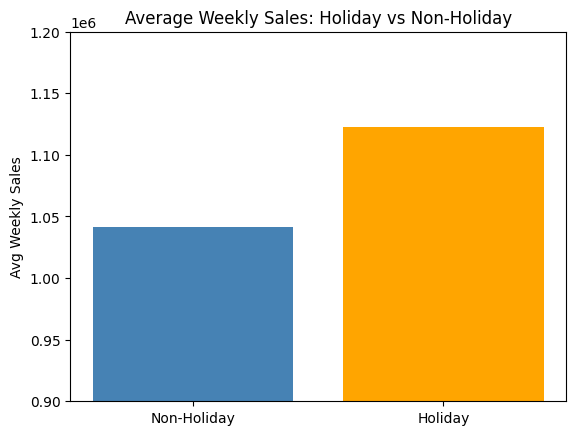

In [11]:
import matplotlib.pyplot as plt

holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.bar(['Non-Holiday', 'Holiday'], holiday_sales, color=['steelblue', 'orange'])
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Avg Weekly Sales')
plt.ylim(900000, 1200000)
plt.show()

## 3. Sales Trend Over Time
Total weekly sales across all 45 stores from 2010–2012, revealing seasonal patterns.

December is the peak month every year, with smaller spikes in April and July — consistent seasonality that makes sales predictable and plannable.

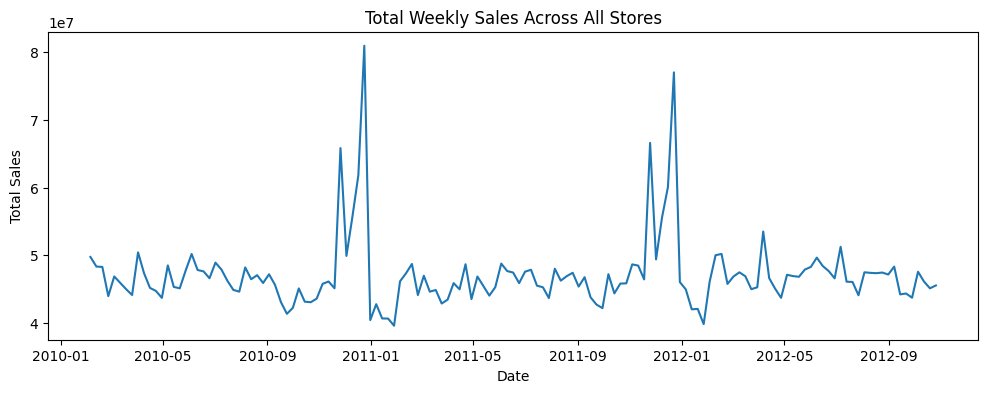

In [12]:
weekly = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12, 4))
plt.plot(weekly.index, weekly.values)
plt.title('Total Weekly Sales Across All Stores')
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.show()

## 4. Top Performing Stores
Store 20 leads all 45 locations with ~2.1M average weekly sales.

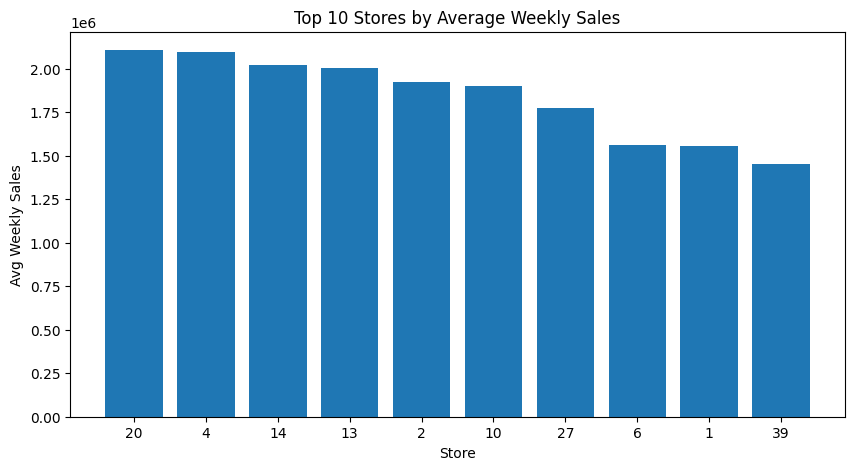

In [13]:
top10 = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10.index.astype(str), top10.values)
plt.title('Top 10 Stores by Average Weekly Sales')
plt.xlabel('Store')
plt.ylabel('Avg Weekly Sales')
plt.show()

## 5. SQL Analysis
Loading the data into SQLite and running queries to validate our pandas findings.

SQL results match pandas exactly — Store 20 leads at 2.1M avg weekly sales, and holiday weeks average 1.12M vs 1.04M for non-holiday weeks.

In [14]:
import sqlite3

conn = sqlite3.connect('walmart.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
print('done')

done


In [15]:
query = """
SELECT Store, ROUND(AVG(Weekly_Sales), 2) AS avg_sales
FROM sales
GROUP BY Store
ORDER BY avg_sales DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
result

,Store,avg_sales
0,20,2107676.87
1,4,2094712.96
2,14,2020978.40
3,13,2003620.31
4,2,1925751.34
5,10,1899424.57
6,27,1775216.20
7,6,1564728.19
8,1,1555264.40
9,39,1450668.13


In [16]:
query2 = """
SELECT Holiday_Flag, ROUND(AVG(Weekly_Sales), 2) AS avg_sales
FROM sales
GROUP BY Holiday_Flag
"""

result2 = pd.read_sql(query2, conn)
result2

,Holiday_Flag,avg_sales
0,0,1041256.38
1,1,1122887.89


## 6. Key Findings
- Holiday weeks drive 7.8% higher average weekly sales
- Store 20 is the top performer at ~2.1M average weekly per week
- Sales show consistent seasonality with peaks in November and December each year
- 45 stores analyzed across 2010–2012, zero missing data points